## 1 · Imports

In [1]:
from anndata import AnnData
from typing import Optional

# Libraries
import anndata as ad
import matplotlib as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.pyplot import rc_context
from scipy.stats import median_abs_deviation

from functools import partial
import altair as alt
import seaborn as sns
import decoupler as dc
from scipy.sparse import csr_matrix
import os
from pathlib import Path

import mudata as mu
import scanpy as sc
import scirpy as ir
import altair as alt
alt.data_transformers.enable("vegafusion")

import anndata as ad
import numpy as np
import palantir

import numpy as np
import scipy.sparse as sp

In [2]:
import muon as mu
from muon import MuData

2026-06-06 18:39:53.434808: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-06 18:39:53.489348: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 2 · Data Loading

Load mudata

In [3]:
mdata = mu.read_h5mu("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/003_trajectory_annotated_mudata.h5mu")

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/anndata/utils.py:354: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adop

In [4]:
rename_dict = {
    "10mix_ICI1": "ctrl1",
    "10mix_ICI2": "ctrl2",
    "11mix_ICI1": "effector1",
    "11mix_ICI2": "effector2",
    "GF_ICI1": "GF_noICI1",
    "GF_ICI2": "GF_noICI2",
    "GF_ICI1_plus": "GF1",
    "GF_ICI2_plus": "GF2"
}

mdata["gex"].obs["sample_id"] = (
    mdata["gex"].obs["sample_id"]
    .replace(rename_dict)
)

/tmp/ipykernel_2627344/2648257632.py:14: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  .replace(rename_dict)


In [5]:
mask = ~mdata["gex"].obs["cell_annotation_05"].isin(["Cycling"])

mdata_without_cycling = mdata[mask, :].copy()

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [6]:
mdata_without_cycling["gex"].obs.cell_annotation_05

10mix-ICI1_AAACCTGAGAGCCTAG-1                 Activated
10mix-ICI1_AAACCTGAGATGTGGC-1           Effector_memory
10mix-ICI1_AAACCTGAGCCACGTC-1      Stem/Resident_memory
10mix-ICI1_AAACCTGAGGCTCTTA-1      Stem/Resident_memory
10mix-ICI1_AAACCTGAGGGCACTA-1           Effector_memory
                                           ...         
GF-ICI2-plus_TTTGTCATCCCTTGCA-1               Activated
GF-ICI2-plus_TTTGTCATCGTTGCCT-1               Activated
GF-ICI2-plus_TTTGTCATCTAACTGG-1    Stem/Resident_memory
GF-ICI2-plus_TTTGTCATCTCTGTCG-1         Effector_memory
GF-ICI2-plus_TTTGTCATCTGTTGAG-1               Activated
Name: cell_annotation_05, Length: 70414, dtype: category
Categories (4, object): ['Activated', 'Effector_memory', 'Exhausted', 'Stem/Resident_memory']

## 3 · Pseudobulk for DGSEA

Running it on mdata_without_cycling for DGSEA we want to avoid the cycling genes that could be misleading

In [7]:
mdata["gex"].obs["all_cd8"] = "all"

In [8]:
mdata.update()

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [9]:
mdata_without_cycling["gex"].obs["all_cd8"] = "all"

In [10]:
mdata_without_cycling.update()

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [11]:
pdata = dc.pp.pseudobulk(
    adata=mdata_without_cycling["gex"],
    sample_col="sample_id",
    groups_col=["all_cd8"],   
    mode="sum",
    empty=False,
    layer="counts",
)

In [12]:
pdata

AnnData object with n_obs × n_vars = 8 × 17581
    obs: 'sample_id', 'all_cd8', 'adata_name', 'condition', 'batch_id', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'group4', 'psbulk_cells', 'psbulk_counts'
    var: 'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
    layers: 'psbulk_props'

In [13]:
#pdata.write_h5ad("pdata.h5ad")

In [14]:
sc.tl.pca(pdata)

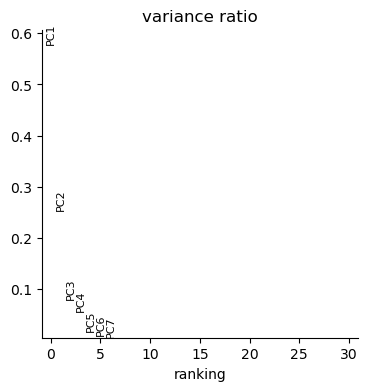

In [15]:
sc.pl.pca_variance_ratio(pdata)

In [16]:
pdata

AnnData object with n_obs × n_vars = 8 × 17581
    obs: 'sample_id', 'all_cd8', 'adata_name', 'condition', 'batch_id', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'group4', 'psbulk_cells', 'psbulk_counts'
    var: 'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
    uns: 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props'

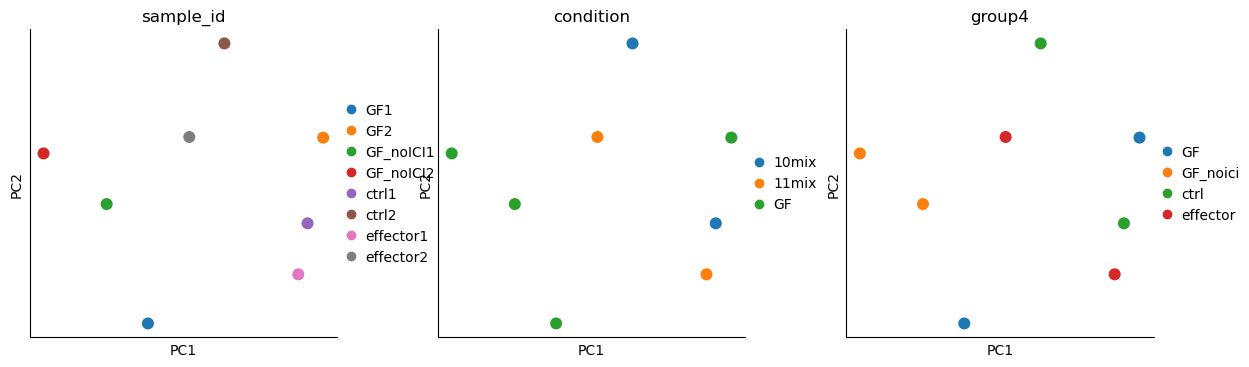

In [17]:
sc.pl.pca(
    pdata,
    color=["sample_id",  "condition","group4"],#,"cell_annotation_05"],
    ncols=3,
    size=300,
    frameon=True,
)

In [18]:
group_map = {
    "ctrl1": "ctrl_ICI",
    "ctrl2": "ctrl_ICI",
    "effector1": "effector_ICI",
    "effector2": "effector_ICI",
    "GF_noICI1": "GF_noICI",
    "GF_noICI2": "GF_noICI",
    "GF1": "GF_ICI",
    "GF2": "GF_ICI",
}

# pdata.obs contains sample_id and cell_annotation_05 after pseudobulk
pdata.obs["group4"] = pdata.obs["sample_id"].map(group_map).astype("category")

# sanity check
print(pdata.obs["group4"].value_counts(dropna=False))

group4
GF_ICI          2
GF_noICI        2
ctrl_ICI        2
effector_ICI    2
Name: count, dtype: int64


In [19]:
# convert to array if sparse
counts = pdata.X

if not isinstance(counts, np.ndarray):
    counts = counts.toarray()

# keep genes with >=10 counts in at least 2 samples
gene_filter = (counts >= 10).sum(axis=0) >= 2

pdata_filtered = pdata[:, gene_filter].copy()

print("Genes before filtering:", pdata.shape[1])
print("Genes after filtering:", pdata_filtered.shape[1])

Genes before filtering: 17581
Genes after filtering: 14385


In [20]:
from scipy import sparse

In [21]:
samplesheet = pdata_filtered.obs.copy()
samplesheet.insert(0, "sample", pdata_filtered.obs_names)

#samplesheet.to_csv("samplesheet.csv", index=False)

X = pdata_filtered.X

if sparse.issparse(X):
    counts_array = X.toarray()
else:
    counts_array = np.asarray(X)

# genes as rows, samples as columns
counts_df = pd.DataFrame(
    counts_array.T,
    index=pdata_filtered.var_names,   # gene_name
    columns=pdata_filtered.obs_names
)


gene_id = pdata_filtered.var["gene_ids"].values      # ENSG...
gene_name = pdata_filtered.var_names.values          # gene symbols

# insert in correct order
counts_df.insert(0, "gene_name", gene_name)
counts_df.insert(0, "gene_id", gene_id)

# optional: ensure integer counts
counts_df.iloc[:, 2:] = counts_df.iloc[:, 2:].round().astype(int)

counts_df.columns = [
    col.replace("_all", "") if col not in ["gene_id", "gene_name"] else col
    for col in counts_df.columns
]

# save
#counts_df.to_csv("counts_matrix.tsv", sep="\t", index=False)

## 4 · Pseudobulk for cytosig

In [22]:
mdata_without_cycling["gex"].obs["all_cd8"] = "all"

pdata = dc.pp.pseudobulk(
    adata=mdata["gex"],
    sample_col="sample_id",
    groups_col=["all_cd8"],   
    mode="sum",
    empty=False,
    layer="counts",
)

In [23]:
#pdata.write_h5ad("pdata_cytosig_with_cycling.h5ad")

In [24]:
mdata_without_cycling["gex"].obs["all_cd8"] = "all"

pdata = dc.pp.pseudobulk(
    adata=mdata_without_cycling["gex"],
    sample_col="sample_id",
    groups_col=["all_cd8"],   
    mode="sum",
    empty=False,
    layer="counts",
)

In [25]:
#pdata.write_h5ad("pdata_cytosig_without_cycling.h5ad")

## 5 · Pseudobulk for by cell type

In [26]:
import os
import numpy as np
import pandas as pd
from scipy import sparse
import decoupler as dc
import scanpy as sc

cell_types = [
    "Activated",
    "Effector_memory",
    "Exhausted",
    "Stem/Resident_memory",
]

outdir = "/data/scratch/kvalem/projects/2021/honda_microbial_metabolites_2021/20_scripts/40_single-cell-sorted-cd8/40_gex_surface_prot/28012026/run_gsea/tables/cell_type"
os.makedirs(outdir, exist_ok=True)

adata = mdata_without_cycling["gex"]

for cell_type in cell_types:

    print(f"Processing {cell_type}...")

    # -----------------------------
    # 1. Subset one cell type
    # -----------------------------
    adata_ct = adata[
        adata.obs["cell_annotation_05"] == cell_type
    ].copy()

    # -----------------------------
    # 2. Pseudobulk by sample
    # -----------------------------
    pdata = dc.pp.pseudobulk(
        adata=adata_ct,
        sample_col="sample_id",
        groups_col="cell_annotation_05",
        mode="sum",
        empty=False,
        layer="counts",
    )

    # Optional PCA QC
    sc.tl.pca(pdata)

    # -----------------------------
    # 3. Create samplesheet
    # -----------------------------
    samplesheet = pdata.obs.copy()
    samplesheet.insert(0, "sample", pdata.obs_names)

    safe_cell_type = cell_type.replace("/", "_")

    samplesheet.to_csv(
        f"{outdir}/samplesheet_{safe_cell_type}.csv",
        index=False
    )

    # -----------------------------
    # 4. Create counts matrix
    # -----------------------------
    X = pdata.X

    if sparse.issparse(X):
        counts_array = X.toarray()
    else:
        counts_array = np.asarray(X)

    counts_df = pd.DataFrame(
        counts_array.T,
        index=pdata.var_names,
        columns=pdata.obs_names
    )
    # Remove the cell-type suffix from sample columns
    counts_df.columns = [
    col.removesuffix(f"_{cell_type}")
    if col not in ["gene_id", "gene_name"]
    else col
    for col in counts_df.columns
    ]

    gene_id = pdata.var["gene_ids"].values
    gene_name = pdata.var_names.values

    counts_df.insert(0, "gene_name", gene_name)
    counts_df.insert(0, "gene_id", gene_id)

    # Ensure integer counts
    counts_df.iloc[:, 2:] = counts_df.iloc[:, 2:].round().astype(int)

    # Optional: clean column names
    counts_df.columns = [
        col.replace("_all", "") if col not in ["gene_id", "gene_name"] else col
        for col in counts_df.columns
    ]

    counts_df.to_csv(
        f"{outdir}/counts_matrix_{safe_cell_type}.tsv",
        sep="\t",
        index=False
    )

Processing Activated...
Processing Effector_memory...
Processing Exhausted...
Processing Stem/Resident_memory...
